<a href="https://colab.research.google.com/github/JessicaSTMatos/Datathon---Fase-5---FIAP/blob/main/Fase_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fase 5 - Datathon**

Nesse Datathon recebemos o desafio de construir um modelo de
Deep Learning, Machine Learning, IA ou outro modelo **capaz de classificar automaticamente o sentimento das
reclamações de clientes** (positivas ou negativas) com base no texto enviado,
e realizar uma análise das principais dores relatadas em cada categoria de
produto financeiro.

Recebemos um conjunto de dados com reclamações de
consumidores sobre produtos e serviços financeiros, contendo o texto da
reclamação, a empresa envolvida e a categoria do produto/serviço (como cartão
de crédito, hipoteca, empréstimo, etc.).

Essas reclamações foram encaminhadas
às empresas e publicadas após confirmação de relacionamento comercial.

O nosso desafio é entender melhor como os consumidores se
sentem em relação a esses serviços e quais problemas são mais recorrentes.

## 1. Preparação dos Dados

1.1 - Instalação e importação das bibliotecas necessárias

In [ ]:
!pip install torch torchvision torchaudio transformers scikit-learn pandas

In [ ]:
import pandas as pd
import torch
import re
import string
import nltk
import spacy
import torch.nn as nn
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm
from nltk.corpus import stopwords
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

Devido ao tamanho da base original e, conforme orientado em aula, utilizamos a base disponibilizda no Kaggle (https://www.kaggle.com/datasets/shashwatwork/consume-complaints-dataset-fo-nlp?resource=download).

 Utilizamos a biblioteca **kagglehub** para baixar o conjunto de dados diretamente do Kaggle. Primeiro, importamos a biblioteca **kagglehub**.

 Em seguida, a função kagglehub.dataset_download() é chamada com o identificador do dataset ('shashwatwork/consume-complaints-dataset-fo-nlp') para fazer o download.

 O caminho local onde os arquivos do dataset são salvos é armazenado na variável path.

 Finalmente, o print() exibe esse caminho, informando onde podemos encontrar os arquivos baixados.

In [ ]:
import kagglehub


path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")

print("Path to dataset files:", path)

100%|██████████| 19.8M/19.8M [00:00<00:00, 47.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1


Após o dataset ter sido baixado e seu caminho estar armazenado na variável path, o próximo passo foi listar o conteúdo do diretório para identificar o arquivo CSV e carregar o arquivo CSV específico a partir desse caminho para um DataFrame do pandas.

In [ ]:
import os

files_in_path = os.listdir(path)
print(f"Files in the directory {path}: {files_in_path}")

Files in the directory /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1: ['complaints_processed.csv']


In [ ]:
csv_file_name = 'complaints_processed.csv'
full_path = os.path.join(path, csv_file_name)
df = pd.read_csv(full_path)

print("O arquivo CSV foi carregado com sucesso em um DataFrame.")
print("Exibindo as 5 primeiras linhas do DataFrame:")
df.head()

O arquivo CSV foi carregado com sucesso em um DataFrame.
Exibindo as 5 primeiras linhas do DataFrame:


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


## 2. Análise Exploratória de Dados (AED)

Optamos por realizar uma análise exploratória inicial dos dados para compreender a estrutura do conjunto de dados, os tipos de dados e identificar possíveis problemas, como valores ausentes, por exemplo.

Para iniciar a Análise Exploratória de Dados verificamos o tamanho da base de dados, a quantidade de categorias de produtos, os tipos de produtos, as estatísticas descritivas, as informações do DataFrame, o número de valores únicos por coluna e os valores ausentes por coluna.

In [ ]:
print("Tamanho da base de dados:")
df.shape


Tamanho da base de dados:


(162421, 4)

In [ ]:
print("Quantidade de categorias de produtos:")
df['product'].nunique()

Quantidade de categorias de produtos:


5

In [ ]:
set(df['product'])

{'credit_card',
 'credit_reporting',
 'debt_collection',
 'mortgages_and_loans',
 'retail_banking'}

In [ ]:
print("\nEstatísticas Descritivas:")
df.describe()



Estatísticas Descritivas:


,Unnamed: 0
count,162421.000000
mean,81210.000000
std,46887.048373
min,0.000000
25%,40605.000000
50%,81210.000000
75%,121815.000000
max,162420.000000


In [ ]:
print("Informações do DataFrame:")
df.info()

print("\nNúmero de valores únicos por coluna:")
print(df.nunique())

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Unnamed: 0         162421 non-null  int64 
 1   product            162421 non-null  object
 2   narrative          162411 non-null  object
 3   narrativa_tratada  162421 non-null  object
dtypes: int64(1), object(3)
memory usage: 5.0+ MB

Número de valores únicos por coluna:
Unnamed: 0           162421
product                   5
narrative            124472
narrativa_tratada    124446
dtype: int64

Valores ausentes por coluna:
Unnamed: 0            0
product               0
narrative            10
narrativa_tratada     0
dtype: int64


Para tratar os valores ausentes identificados na coluna 'narrative' removemos as linhas correspondentes do DataFrame usando o método dropna() e, em seguida, verificamos a operação novamente para ter certeza que não há mais a presença de valores ausentes.

In [ ]:
print("Formato do DataFrame antes da remoção de valores nulos:", df.shape)
df.dropna(subset=['narrative'], inplace=True)
print("Formato do DataFrame após da remoção de valores nulos::", df.shape)

print("\nValores ausentes por coluna após a remoção de linhas:")
print(df.isnull().sum())

Formato do DataFrame antes da remoção de valores nulos: (162421, 4)
Formato do DataFrame após da remoção de valores nulos:: (162411, 4)

Valores ausentes por coluna após a remoção de linhas:
Unnamed: 0           0
product              0
narrative            0
narrativa_tratada    0
dtype: int64


Optamos por criar um gráfico de barras que mostra a contagem de cada categoria de produto no DataFrame utilizando as bibliotecas matplotlib.pyplot e seaborn para a visualização.

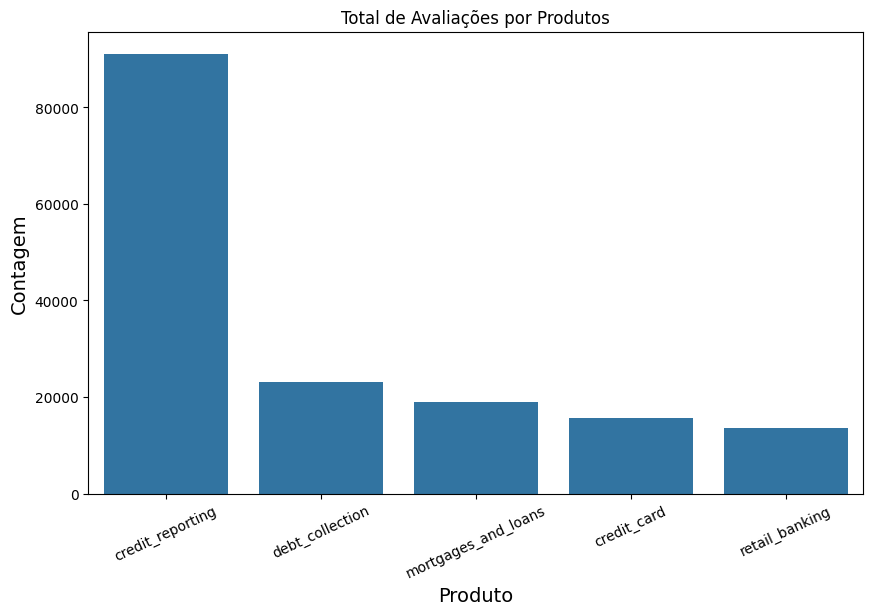

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='product', order=df['product'].value_counts().index)
plt.title('Total de Avaliações por Produtos')
plt.xlabel('Produto', size=14)
plt.xticks(rotation=25)
plt.ylabel('Contagem', size=14)
plt.show()

## 3. Pré-processamento do texto


Para que um modelo estatístico ou de Deep Learning performe bem nessa base de reclamações financeiras, o pré-processamento deve focar em reduzir o ruído (como as máscaras XXXX) e normalizar termos técnicos.

Como estamos trabalhando com o Consumer Complaints Dataset, que é originalmente em inglês, optamos por utilizar a biblioteca spaCy para lematização, pois ela é superior ao Stemming por manter o sentido semântico das palavras (ex: transforma "banking", "banks" e "banked" apenas em "bank").

In [ ]:
# Carregamos o modelo de inglês do spaCy para lematização
# O 'disable' acelera o processo ignorando partes que não usaremos
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Baixamos as stopwords do NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Ativamos barra de progresso no pandas
tqdm.pandas()

Optamos por aplicar as estratégias de Regex, Normalização e Lematização em uma única passagem para ser mais eficiente.

In [ ]:
def preprocessar_narrativa(texto):
    if not isinstance(texto, str):
        return ""

    # 1. Regex: Limpamos as máscaras 'XXXX' do dataset
    texto = re.sub(r'X+', '', texto)

    # 2. Regex: Removemos números e pontuação
    texto = re.sub(r'\d+', '', texto)
    texto = texto.translate(str.maketrans('', '', string.punctuation))

    # 3. Normalização: Minúsculas e espaços
    texto = texto.lower().strip()

    # 4. Lematização e Remoção de Stopwords
    doc = nlp(texto)
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and not token.is_space]

    return " ".join(tokens)

Como essa base tem centenas de milhares de linhas, optar por aplicar a função em tudo de uma vez pode levar muito tempo ou travar a RAM. A estratégia que adotamos foi testar em uma amostra significativa primeiro.

In [ ]:
# 1. Verificamos os nomes das colunas (O texto pode estar em 'narrative' ou 'Consumer complaint narrative')
print("Colunas disponíveis:", df.columns)

# 2. Criamos uma amostra para não travar (ex: 10.000 linhas)
df_limpo = df.sample(10000, random_state=42).copy()

# 3. Aplicamos a função com barra de progresso
print("Iniciando o processamento... Isso pode levar de 2 a 5 minutos para 10k linhas.")
df_limpo['narrativa_tratada'] = df_limpo['narrative'].progress_apply(preprocessar_narrativa)

# 4. Resultado final
print("\nProcessamento concluído!")
print(df_limpo[['narrative', 'narrativa_tratada']].head())

Colunas disponíveis: Index(['Unnamed: 0', 'product', 'narrative'], dtype='object')
Iniciando o processamento... Isso pode levar de 2 a 5 minutos para 10k linhas.


100%|██████████| 10000/10000 [02:26<00:00, 68.43it/s]


Processamento concluído!
                                                narrative  \
156566  penfed asking copy driver license finalizing l...   
1498    collection account removed credit report frank...   
134991  bureau falsely reporting alleged debt fdcpa se...   
56391   va mortgage well fargo bank since meet conditi...   
9067                          bank xxxxi credit card mine   

                                        narrativa_tratada  
156566  penfe ask copy driver license finalize loan am...  
1498    collection account remove credit report frankl...  
134991  bureau falsely report allege debt fdcpa sectio...  
56391   va mortgage well fargo bank since meet conditi...  
9067                          bank xxxxi credit card mine  


Optamos por fazer uma preparação para processamento em massa da base toda. Configuramos o spaCy para trabalhar com máxima eficiência, desativando componentes desnecessários da rede neural (como o identificador de entidades e o parser gramatical). Em vez de processar linha por linha, o spaCy processará o texto em blocos.

In [ ]:
# Carregamos o modelo em inglês e desativamos o que não usaremos para ganhar velocidade
nlp = spacy.load("en_core_web_sm", disable=['ner', 'parser', 'tok2vec', 'attribute_ruler'])

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def limpar_basico(texto):
    """ Limpeza rápida via Regex antes de enviar para o spaCy """
    if not isinstance(texto, str): return ""
    texto = re.sub(r'X+', '', texto) # Removemos máscaras XXXX
    texto = re.sub(r'\d+', '', texto) # Removemos números
    texto = texto.translate(str.maketrans('', '', string.punctuation)) # Removemos pontuação
    return texto.lower().strip()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# 1. Preparamos dos dados brutos
print("Realizando limpeza inicial com Regex...")
textos_brutos = [limpar_basico(t) for t in df['narrative']]

# 2. Processamos em massa com spaCy
textos_processados = []

print("Iniciando Lematização e Stopwords em massa (nlp.pipe)...")
# n_process=-1 usa todos os núcleos da CPU do Colab
# batch_size controla quantos textos são enviados por vez
for doc in nlp.pipe(textos_brutos, batch_size=1000, n_process=-1):
    # Lematização e remoção de stopwords em uma linha
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and not token.is_space]
    textos_processados.append(" ".join(tokens))

# 3. Guardamos o resultado de volta no DataFrame original
df['narrativa_tratada'] = textos_processados

print("\nConcluído! A base inteira foi processada.")

Realizando limpeza inicial com Regex...
Iniciando Lematização e Stopwords em massa (nlp.pipe)...


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)



Concluído! A base inteira foi processada.


Como o processamento da base inteira é uma tarefa pesada, optamos por salvar o resultado imediatamente em Parquet no disco temporário e baixar o arquivo no computador.

In [ ]:
# Salvamos no disco temporário do Colab em formato Parquet (mais rápido e leve que CSV)
#df.to_parquet('complaints_completo_tratado.parquet')

# Baixamos o arquivo para o computador
#from google.colab import files
#files.download('complaints_completo_tratado.parquet')

## 4. Definição da variável alvo (*target*)

De acordo com as instruções do Datathon é necessária a criação de uma variável alvo (*target*) e criação da coluna "sentimento" para classificar as reclamações como "positiva" ou "negativa"

Dado que é necessário haver uma de precisão no modelo, sem rotular milhares de dados manualmente, optamos uma Abordagem Léxica + Regras (VADER) - Como o dataset é em inglês, o VADER é muito eficaz para identificar sentimentos em textos de redes sociais e reclamações. Ele usa um dicionário de palavras com "pesos" de negatividade.

In [ ]:
# Criamos a coluna de Sentimento (Target)
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

def categorizar_sentimento(texto):
    if not texto: return 'Neutra'
    score = sia.polarity_scores(texto)['compound']
    if score <= -0.05: return 'Negativa'
    elif score >= 0.05: return 'Positiva'
    else: return 'Neutra'

print("Rotulando sentimentos... (Aguarde)")
df['sentimento'] = df['narrativa_tratada'].apply(categorizar_sentimento)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Rotulando sentimentos... (Aguarde)


In [ ]:
print(f"Distribuição de sentimentos:\n{df['sentimento'].value_counts()}")

Distribuição de sentimentos:
sentimento
Positiva    89235
Negativa    63759
Neutra       9417
Name: count, dtype: int64


In [ ]:
# Excluímos a categoria 'Neutra' para focar na classificação binária solicitada
df_final = df[df['sentimento'] != 'Neutra'].copy()

In [ ]:
# Transformamos Sentimento em Números (0 = Negativa, 1 = Positiva)
le_sentimento = LabelEncoder()
df_final['target'] = le_sentimento.fit_transform(df_final['sentimento'])
num_classes = len(le_sentimento.classes_)

print(f"Distribuição de sentimentos:\n{df_final['sentimento'].value_counts()}")

Distribuição de sentimentos:
sentimento
Positiva    89235
Negativa    63759
Name: count, dtype: int64


In [ ]:
# Verificamos como ficou o df após a preparação dos dados

df_final.head(20)

,Unnamed: 0,product,narrative,narrativa_tratada,sentimento,target
0,0,credit_card,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...,Positiva,1
1,1,credit_card,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...,Positiva,1
2,2,retail_banking,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...,Negativa,0
6,6,credit_reporting,va date complaint experian credit bureau invol...,va date complaint experian credit bureau invol...,Negativa,0
7,7,credit_reporting,account reported abbreviated name full name se...,account reported abbreviated name full name se...,Negativa,0
8,8,credit_reporting,account reported abbreviated name full name se...,account reported abbreviated name full name se...,Negativa,0
9,9,credit_reporting,usdoexxxx account reported abbreviated name fu...,usdoexxxx account reported abbreviated name fu...,Negativa,0
10,10,mortgages_and_loans,beginning mortgage held mb financial mb mortga...,beginning mortgage held mb financial mb mortga...,Negativa,0
11,11,credit_card,called request new york state covid relief pla...,called request new york state covid relief pla...,Positiva,1
12,12,credit_card,capital one secured credit account opened name...,capital one secured credit account opened name...,Positiva,1


## 3. Vetorização e Preparação Final dos Dados

Optamos pelo uso de **Word Embeddings** como técnica de vetorização.

Diferente de técnicas baseadas apenas em frequência de palavras, as **Word Embeddings** representam termos em um espaço vetorial denso onde palavras com significados similares (ex: "empréstimo" e "financiamento") ficam próximas matematicamente. Isso permite que o modelo entenda que a "dor" do cliente é a mesma, mesmo que ele utilize sinônimos diferentes.

Enquanto o **TF-IDF** cria matrizes gigantescas e esparsas (com muitos zeros), as **Embeddings** comprimem a informação em vetores menores e mais informativos. Isso torna o treinamento de modelos de Deep Learning, como a LSTM, muito mais eficiente e menos propenso ao "vício" de decorar palavras isoladas.

No setor financeiro, a ordem das palavras altera drasticamente o sentido (ex: "taxa de juros alta" vs "juros de taxa alta"). As **Embeddings** preservam a relação sintática e semântica entre os termos, permitindo que a rede neural identifique padrões de reclamações complexas de forma mais precisa.

Esta técnica é o padrão ouro para alimentar arquiteturas neurais, pois permite que o modelo aprenda representações de dados mais profundas durante o treinamento, adaptando-se especificamente ao vocabulário técnico e às gírias do setor bancário presentes na nossa base de dados.

In [ ]:
# Configurações de Vetorização
max_words = 20000
max_len = 100 # Reduzimos para 100 para ganhar velocidade no treino

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df_final['narrativa_tratada'])

sequences = tokenizer.texts_to_sequences(df_final['narrativa_tratada'])
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
y = df_final['target'].values

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Verificamos como ficou o df após a preparação dos dados

df_final.head(20)

,Unnamed: 0,product,narrative,narrativa_tratada,sentimento,target
0,0,credit_card,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...,Positiva,1
1,1,credit_card,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...,Positiva,1
2,2,retail_banking,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...,Negativa,0
6,6,credit_reporting,va date complaint experian credit bureau invol...,va date complaint experian credit bureau invol...,Negativa,0
7,7,credit_reporting,account reported abbreviated name full name se...,account reported abbreviated name full name se...,Negativa,0
8,8,credit_reporting,account reported abbreviated name full name se...,account reported abbreviated name full name se...,Negativa,0
9,9,credit_reporting,usdoexxxx account reported abbreviated name fu...,usdoexxxx account reported abbreviated name fu...,Negativa,0
10,10,mortgages_and_loans,beginning mortgage held mb financial mb mortga...,beginning mortgage held mb financial mb mortga...,Negativa,0
11,11,credit_card,called request new york state covid relief pla...,called request new york state covid relief pla...,Positiva,1
12,12,credit_card,capital one secured credit account opened name...,capital one secured credit account opened name...,Positiva,1


## 4. Arquitetura do Modelo de Deep Learning - Rede Neural recorrente LSTM (Long Short-Term Memory)

A escolha da rede neural recorrente LSTM (Long Short-Term Memory) para a classificação de sentimentos em reclamações bancárias é uma decisão estratégica fundamentada na natureza sequencial e complexa da linguagem humana.

Diferente de modelos estatísticos simples, a LSTM possui "portões" (*gates*) que permitem decidir quais informações de uma frase longa devem ser mantidas ou descartadas, preservando o contexto do início da reclamação até o fim.

No setor financeiro, a ordem das palavras altera drasticamente o sentido (ex: "o banco não estornou o valor" vs "o banco estornou o valor não solicitado"). A LSTM é projetada especificamente para entender essas relações de dependência entre palavras distantes.

Redes neurais comuns costumam "esquecer" o início de textos longos durante o treinamento. A arquitetura da LSTM resolve o problema do gradiente que desaparece, garantindo que o aprendizado seja estável mesmo em narrativas de reclamações extensas.

Ao trabalhar em conjunto com as Word Embeddings, a LSTM consegue interpretar ironias, negações e termos técnicos financeiros de forma muito mais profunda do que métodos que apenas contam a frequência de palavras.

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(x)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden))

In [ ]:
# Configuramos o dispositivo e o modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SentimentLSTM(max_words, 128, 64, num_classes).to(device)

In [ ]:
# Preparamos o DataLoaders
train_data = TensorDataset(torch.from_numpy(X_train).long(), torch.from_numpy(y_train).long())
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Loop de Treino
model.train()
print(f"Iniciando treinamento em: {device}")
for epoch in range(3): # 3 épocas para teste rápido
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Época {epoch+1} - Loss: {total_loss/len(train_loader):.4f}")

Iniciando treinamento em: cpu
Época 1 - Loss: 0.4028
Época 2 - Loss: 0.2461
Época 3 - Loss: 0.1832


**4.1 - Avaliação do Modelo**

Para avaliar o sucesso de um modelo de Deep Learning, não basta olhar apenas para a Acurácia, pois ela pode ser enganosa se a base estiver desbalanceada (por exemplo, se houver muito mais reclamações negativas do que positivas).

Optamos por utilizar um conjunto de métricas que analisam o erro sob diferentes perspectivas para validar modelos de NLP.

* Precisão (Precision): De todas as reclamações que o modelo disse ser "Negativa", quantas eram realmente negativas? (Evita "falsos alarmes").

* Recall (Sensibilidade): De todas as reclamações negativas que realmente existem na base, quantas o modelo conseguiu capturar? Esta é a métrica mais importante para bancos, pois ignorar uma reclamação real (Falso Positivo) é mais custoso do que investigar um elogio por engano.

* F1-Score: É a média harmônica entre Precisão e Recall. É a melhor métrica única para dizer se o modelo é robusto.

* Matriz de Confusão: Uma tabela que mostra onde o modelo está "confuso" (ex: confundindo reclamações neutras com negativas).

--- Relatório de Performance ---
              precision    recall  f1-score   support

    Negativa       0.91      0.88      0.89     12762
    Positiva       0.92      0.94      0.93     17837

    accuracy                           0.91     30599
   macro avg       0.91      0.91      0.91     30599
weighted avg       0.91      0.91      0.91     30599



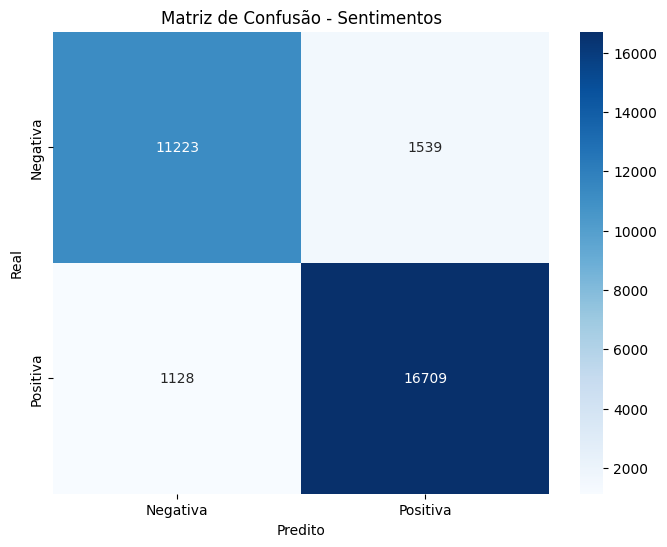

Acurácia Final: 91.28%


In [ ]:
# Avaliamos a Performance

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# 1. Colocamos o modelo em modo de avaliação
model.eval()

y_pred_list = []
y_true_list = []

# 2. Realizamos predições no conjunto de teste (X_test)
with torch.no_grad():
    # Convertemos X_test para tensor e movendo para o dispositivo (GPU/CPU)
    X_test_t = torch.tensor(X_test, dtype=torch.long).to(device)

    # O modelo retorna as probabilidades (logits)
    outputs = model(X_test_t)

    # Pegamos a classe com maior probabilidade
    _, y_pred_tags = torch.max(outputs, dim=1)

    y_pred_list = y_pred_tags.cpu().numpy()
    y_true_list = y_test

# 3. Geramos o Relatório de Classificação
print("--- Relatório de Performance ---")
print(classification_report(y_true_list, y_pred_list, target_names=le_sentimento.classes_))

# 4. Plotamos a Matriz de Confusão
cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sentimento.classes_,
            yticklabels=le_sentimento.classes_)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Sentimentos')
plt.show()

print(f"Acurácia Final: {accuracy_score(y_true_list, y_pred_list)*100:.2f}%")

Para fazer mais uma análise da performance do modelo optamos por fazer um Teste de Inferência que é uma validação qualitativa.

In [ ]:
def prever_sentimento(frase):
    # 1. Aplicar o mesmo pré-processamento que usamos no treino
    # Se você ainda tiver a função 'preprocessar_narrativa' carregada, use-a:
    frase_limpa = preprocessar_narrativa(frase)

    # 2. Vetorização (Transformar em números usando o tokenizer do treino)
    sequencia = tokenizer.texts_to_sequences([frase_limpa])
    padded = pad_sequences(sequencia, maxlen=100, padding='post', truncating='post')

    # 3. Converter para Tensor e passar pelo modelo
    tensor_input = torch.tensor(padded, dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor_input)
        _, predicao = torch.max(output, dim=1)

    # 4. Traduzir o número de volta para a palavra (Positiva/Negativa)
    classe = le_sentimento.inverse_transform(predicao.cpu().numpy())[0]

    # Calcular probabilidade (opcional, para ver a confiança do modelo)
    probabilidades = torch.softmax(output, dim=1)
    confianca = torch.max(probabilidades).item() * 100

    return f"Sentimento: {classe} ({confianca:.2f}% de confiança)"

# --- TESTANDO AGORA ---
frase_teste = "I am very happy because the bank fixed my credit card limit today!"
print(f"Frase: {frase_teste}")
print(prever_sentimento(frase_teste))

print("-" * 30)

frase_teste_2 = "This bank is a disaster, they charged me twice and no one answers the phone."
print(f"Frase: {frase_teste_2}")
print(prever_sentimento(frase_teste_2))

Frase: I am very happy because the bank fixed my credit card limit today!
Sentimento: Positiva (99.89% de confiança)
------------------------------
Frase: This bank is a disaster, they charged me twice and no one answers the phone.
Sentimento: Negativa (99.59% de confiança)


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


## 5. Business Inteligence

Agora que temos o modelo validado com excelentes métricas, o próximo passo foi transformar esses dados em **inteligência de negócio**. Identificar as "dores" específicas de cada produto permite que a instituição financeira tome decisões preventivas.

Para isso, a técnica que utilizamos foi a Extração de N-grams (Bigramas). Em vez de olhar apenas palavras soltas (como "cartão"), olhamos combinações (como "limite_cartão", "cobrança_indevida"), que dão muito mais contexto sobre o problema.

**5.1 - Extraindo as "Dores" por Produto**

In [ ]:
def extrair_principais_dores(df, produto, top_n=5):
    # 1. Filtrar pelo produto e apenas reclamações negativas
    subset = df[(df['product'] == produto) & (df['sentimento'] == 'Negativa')]

    if subset.empty:
        return "Nenhuma reclamação negativa encontrada para este produto."

    # 2. Configurar o Vectorizer para pegar Bigramas (duplas de palavras)
    vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=100)
    bag_of_words = vectorizer.fit_transform(subset['narrativa_tratada'])

    # 3. Somar a frequência de cada bigrama
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return words_freq[:top_n]

# Exemplo: Rodar para os principais produtos da base
principais_produtos = df['product'].value_counts().nlargest(5).index

print("--- ANÁLISE DE DORES POR CATEGORIA ---")
for prod in principais_produtos:
    print(f"\nproduto: {prod}")
    dores = extrair_principais_dores(df, prod)
    for dor, freq in dores:
        print(f"  - {dor}: {freq} ocorrências")

--- ANÁLISE DE DORES POR CATEGORIA ---

produto: credit_reporting
  - credit report: 21049 ocorrências
  - identity theft: 14178 ocorrências
  - reporting agency: 11235 ocorrências
  - consumer reporting: 8295 ocorrências
  - credit reporting: 7194 ocorrências

produto: debt_collection
  - credit report: 5082 ocorrências
  - debt collection: 2394 ocorrências
  - debt collector: 2309 ocorrências
  - collection agency: 2291 ocorrências
  - identity theft: 1998 ocorrências

produto: mortgages_and_loans
  - mortgage company: 1084 ocorrências
  - customer service: 1068 ocorrências
  - mortgage payment: 996 ocorrências
  - make payment: 991 ocorrências
  - escrow account: 892 ocorrências

produto: credit_card
  - credit card: 3373 ocorrências
  - capital one: 1960 ocorrências
  - customer service: 1340 ocorrências
  - bank america: 1191 ocorrências
  - fraudulent charge: 813 ocorrências

produto: retail_banking
  - bank america: 1985 ocorrências
  - checking account: 1816 ocorrências
  - deb

**5.2 - Visualização: Gráfico de Barras das Dores**

/tmp/ipython-input-403/3237419328.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(contagens), y=list(palavras), palette='Reds_r')


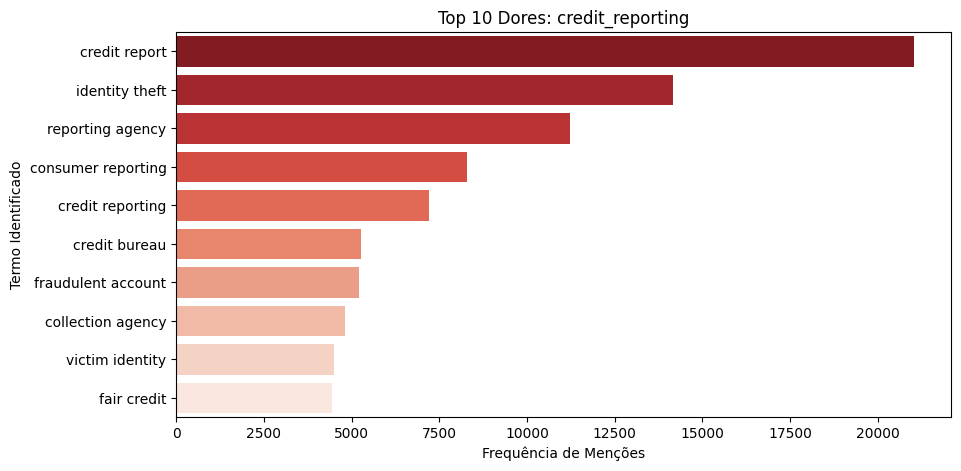

In [ ]:
def plotar_dores(produto):
    dores = extrair_principais_dores(df, produto, top_n=10)
    if isinstance(dores, str): return print(dores)

    palavras, contagens = zip(*dores)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(contagens), y=list(palavras), palette='Reds_r')
    plt.title(f"Top 10 Dores: {produto}")
    plt.xlabel("Frequência de Menções")
    plt.ylabel("Termo Identificado")
    plt.show()

# Escolha um produto para visualizar
plotar_dores(principais_produtos[0])

**5.3 - Visualização: Distribuição de Sentimentos**

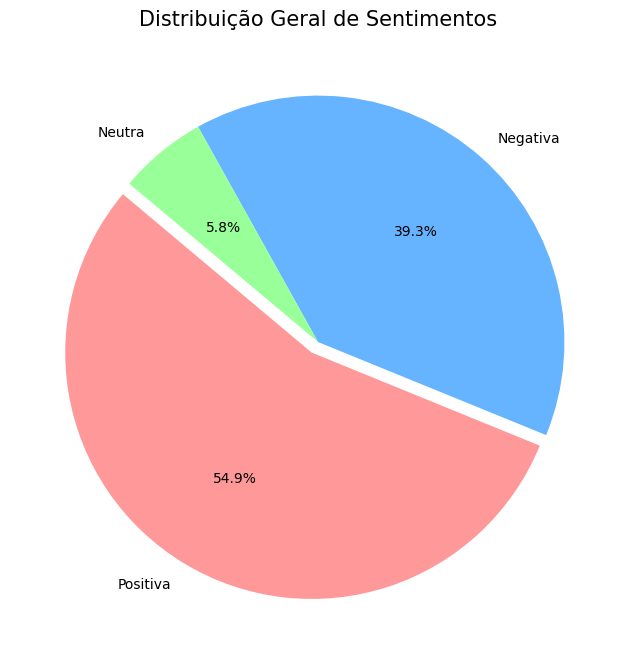

In [ ]:
# --- Distribuição de Sentimentos (Pizza) ---
plt.figure(figsize=(8, 8))
cores = ['#ff9999','#66b3ff','#99ff99']
df['sentimento'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=cores, explode=(0.05, 0, 0))
plt.title('Distribuição Geral de Sentimentos', fontsize=15)
plt.ylabel('')
plt.show()

**5.4 - Visualização: Produtos com mais reclamações**

/tmp/ipython-input-403/3512075029.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_produtos.values, y=top_produtos.index, palette='Reds_r')


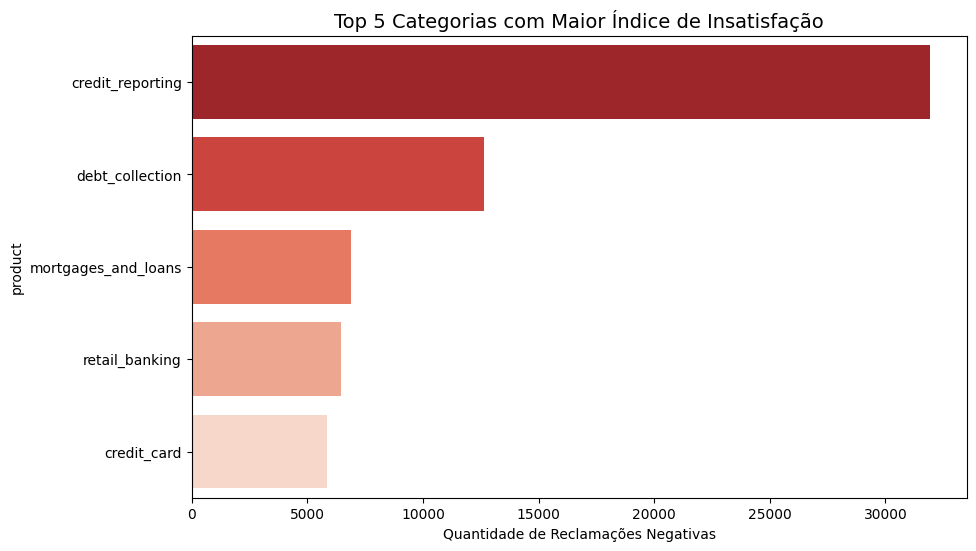

In [ ]:
# --- Top 5 Produtos com Mais Reclamações Negativas ---
plt.figure(figsize=(10, 6))
df_negativo = df[df['sentimento'] == 'Negativa']
top_produtos = df_negativo['product'].value_counts().nlargest(5)

sns.barplot(x=top_produtos.values, y=top_produtos.index, palette='Reds_r')
plt.title('Top 5 Categorias com Maior Índice de Insatisfação', fontsize=14)
plt.xlabel('Quantidade de Reclamações Negativas')
plt.show()

**5.5 - Visualização: Nuvem de Palavras**

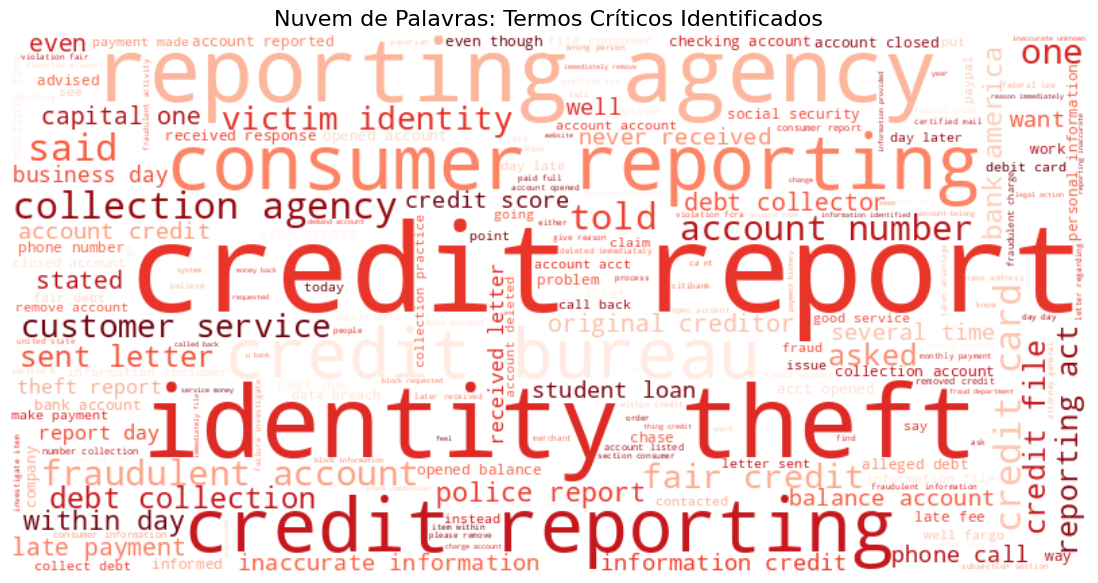

In [ ]:
# --- Nuvem de Palavras (As "Vozes" dos Clientes) ---
# Agrupamos as palavras mais comuns nas narrativas negativas
texto_negativo = " ".join(review for review in df_negativo['narrativa_tratada'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(texto_negativo)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Nuvem de Palavras: Termos Críticos Identificados', fontsize=16)
plt.show()

**5.6 - Visualização: Análise de Bigramas (Dores Específicas)**

/tmp/ipython-input-403/4216857758.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequência', y='Dor', data=df_dores, palette='YlOrRd_r')


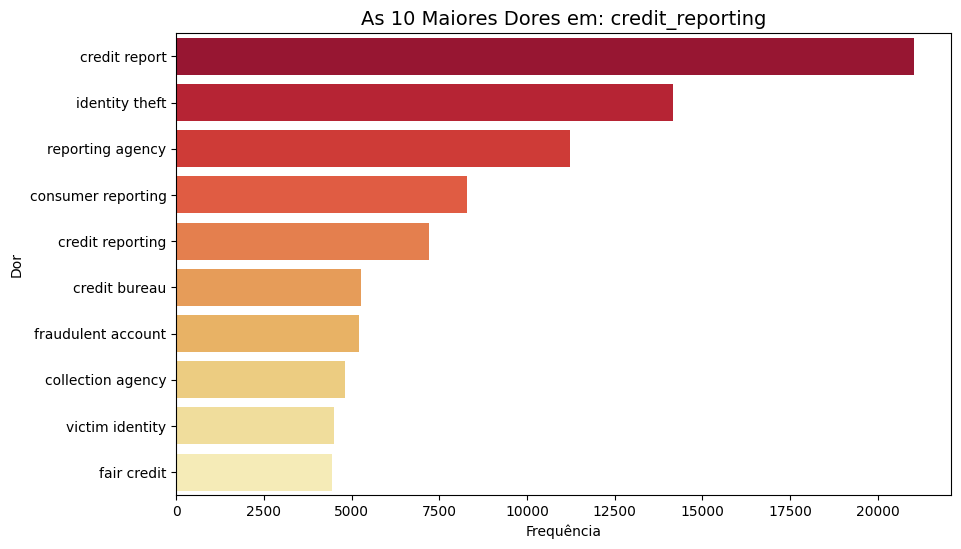

In [ ]:
# Optamos por olhar para o produto com mais reclamações (ex: Credit Card)
top_prod = top_produtos.index[0]
subset = df_negativo[df_negativo['product'] == top_prod]

vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=10)
bag_of_words = vectorizer.fit_transform(subset['narrativa_tratada'].astype(str))
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

df_dores = pd.DataFrame(words_freq, columns=['Dor', 'Frequência'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequência', y='Dor', data=df_dores, palette='YlOrRd_r')
plt.title(f'As 10 Maiores Dores em: {top_prod}', fontsize=14)
plt.show()

**5.7 - Principais temas de insatisfação**

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Filtramos apenas as reclamações negativas (o foco da dor)
df_negativo = df[df['sentimento'] == 'Negativa'].copy()

# 2. Vetorizamos com TF-IDF (pesa palavras importantes e ignora termos comuns)
# Usamos max_features=5000 para ser rápido e preciso
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2, stop_words='english', max_features=5000)
dtm = vectorizer.fit_transform(df_negativo['narrativa_tratada'].astype(str))

# 3. Aplicamos o modelo LDA
# n_components=5 define que queremos encontrar os 5 principais "temas"
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

# 4. Exibimos os temas encontrados
def exibir_temas(modelo, feature_names, n_palavras):
    for index, tema in enumerate(modelo.components_):
        print(f"\n--- TEMA #{index+1} ---")
        print([feature_names[i] for i in tema.argsort()[-n_palavras:]])

# Executamos a exibição
palavras_chave = vectorizer.get_feature_names_out()
exibir_temas(lda, palavras_chave, 10)


--- TEMA #1 ---
['violation', 'letter', 'dispute', 'consumer', 'debt', 'credit', 'report', 'reporting', 'information', 'account']

--- TEMA #2 ---
['credit', 'data', 'unknown', 'breach', 'acct', 'account', 'immediately', 'item', 'deleted', 'day']

--- TEMA #3 ---
['check', 'time', 'payment', 'charge', 'called', 'told', 'money', 'account', 'card', 'bank']

--- TEMA #4 ---
['collection', 'report', 'late', 'company', 'paid', 'loan', 'account', 'credit', 'payment', 'debt']

--- TEMA #5 ---
['fraud', 'remove', 'inquiry', 'victim', 'credit', 'fraudulent', 'report', 'theft', 'identity', 'account']


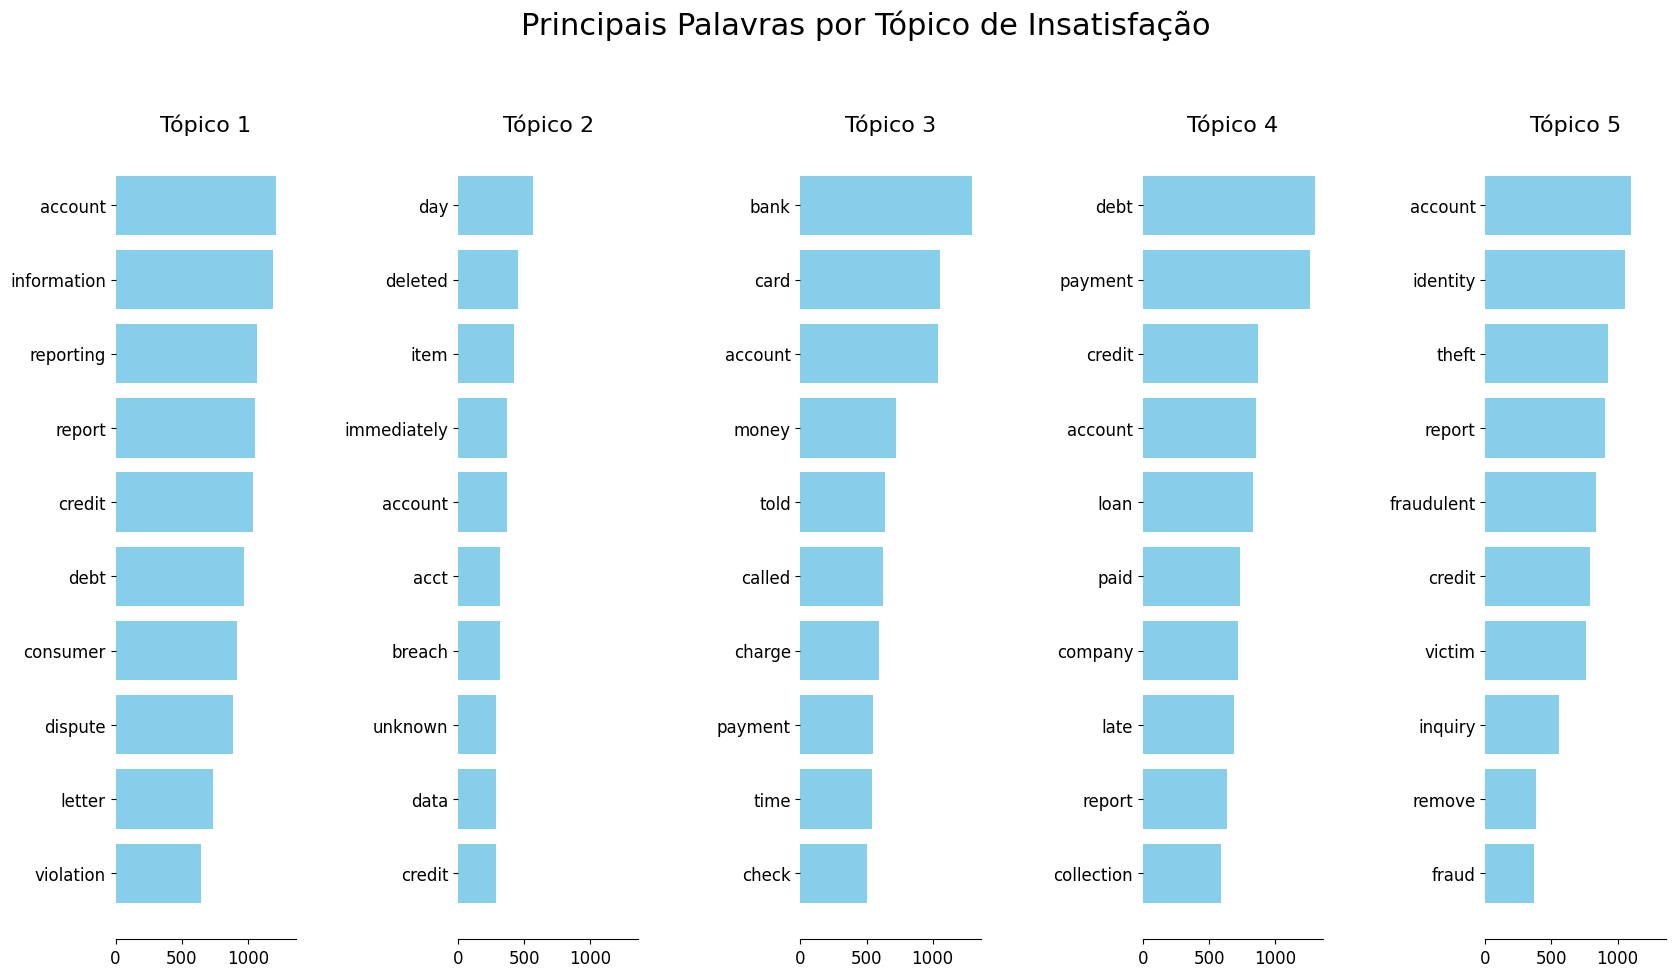

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_words(model, feature_names, n_top_words, title):
    # Configura a grade de subplots (ajuste conforme o número de tópicos - n_components)
    fig, axes = plt.subplots(1, 5, figsize=(20, 10), sharex=True)
    axes = axes.flatten()

    for topic_idx, topic in enumerate(model.components_):
        # Seleciona os índices das palavras com os maiores pesos
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, color='skyblue')
        ax.set_title(f"Tópico {topic_idx + 1}", fontdict={"fontsize": 16})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)

        # Remove bordas para ficar mais limpo
        for i in ["top", "right", "left"]:
            ax.spines[i].set_visible(False)

    fig.suptitle(title, fontsize=22)
    plt.subplots_adjust(top=0.85, bottom=0.05, wspace=0.90)
    plt.show()

# Executando a visualização
palavras_chave = vectorizer.get_feature_names_out()
plot_top_words(lda, palavras_chave, 10, "Principais Palavras por Tópico de Insatisfação")

Validação com a coluna "Issue"

Ao unir o seu modelo de Deep Learning (LSTM) com essa análise de tópicos (LDA), você prova que sua solução não apenas "sente" se o cliente está bravo, mas entende exatamente por que ele está bravo. Isso é o que transforma dados em estratégia bancária.

# **Falta:**
* Avaliar a performance com métricas de validação de modelos
* Realizar uma análise das principais dores relatadas em cada categoria de
produto financeiro
* Entender melhor como os consumidores se
sentem em relação a esses serviços e quais problemas são mais recorrentes
* Gere visualizações (nuvem de palavras, gráfico de frequência) com os termos mais comuns nas reclamações negativas, por categoria de
produto
* Identifique os principais temas de insatisfação (ex: cobrança indevida, falha no atendimento, problemas com estorno).








# **Entregáveis:**

* Repositório do GithHub com o código com pipeline de NLP e modelo
de classificação.
* Análise dos principais termos/temas negativos por categoria.
* Gráficos ou visualizações que ajudem a entender o sentimento dos clientes.
* Vídeo de até 5 (cinco) minutos apresentando as principais dores e o sentimento dos clientes nas ligações.